In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-quality-dataset/Air Quality Benchmark dataset.csv


<a id='back'></a>
# Background
 [Air quality](https://www.kaggle.com/datasets/avibagul80/air-quality-dataset) in Frankfurt has been monitored between the 31/12/2018 and the 20/02/2020. Some observations in relation to time, weather, air pollution (PM 2.5) values collected from some sense-boxes installed in 14 locations scattered in Frankfurt, Germany. 
 
 An [Air quality dataset](https://www.kaggle.com/datasets/avibagul80/air-quality-dataset) has been made available in publicly. The dataset has the following data:
 
 
* __temperatures__
* __pressure__
* __humidity__
* __wind speed__
* __peak or no peak__: 0: 'Peak', 1: 'No_Peak'
* __time of day__ : 0: 'Evening_Hours', 1: 'Night_Hours', 2: 'Morning_Hours', 3: 'Afternoon_Hours'
* __day__ : 0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
* __week day__ : 0: 'Workday', 1: 'Weekend'
* __weather__ : 0: 'Clouds',
  1: 'Mist',
  2: 'Fog',
  3: 'Rain',
  4: 'Drizzle',
  5: 'Drizzle + Rain',
  6: 'Clear',
  7: 'Snow',
  8: 'Snow + Mist',
  9: 'Drizzle + Snow + Mist',
  10: 'Drizzle + Rain + Mist',
  11: 'Drizzle + Mist',
  12: 'Rain + Snow',
  13: 'Rain + Mist',
  14: 'Mist + Fog',
  15: 'Thunderstorm + Rain',
  16: 'Squall',
  17: 'Haze',
  18: 'Thunderstorm',
  19: 'Thunderstorm + Squall',
  20: 'Rain + Fog',
  21: 'Snow + Mist + Fog',
  22: 'Snow + Fog'}
* __lattitude__
* __longitude__
* __pm 2.5 level__: see explanation below 


A PM 2.5 level obtained following the range of values

* Between [0 and 10] - lowest risks to increase pulmonary disease - PM 2.5 Level 1

* Between ]10 and 15],  PM 2.5 level = 2
* Between ]15 and 25],  PM 2.5 level = 3
* Between ]25 and 35],  PM 2.5 level = 4
* PM 2.5 > 35, PM 2.5 level = 5 - long term mortality risks





 

# Loading the data


In [2]:
data = pd.read_csv('../input/air-quality-dataset/Air Quality Benchmark dataset.csv')
data.head(5)

,Time_stamp,boxName,PM 2.5,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,Weather Description,label
0,2018-12-31 18:30:12,iGude,18.20,7.71,1032,100,3.09,Evening_Hours,Peak,Monday,Workday,Clouds,broken clouds,normal
1,2018-12-31 18:32:41,iGude,19.27,7.71,1032,100,3.09,Evening_Hours,Peak,Monday,Workday,Clouds,broken clouds,normal
2,2018-12-31 18:35:11,iGude,18.57,7.71,1032,100,3.09,Evening_Hours,Peak,Monday,Workday,Clouds,broken clouds,normal
3,2018-12-31 18:37:41,iGude,17.85,7.71,1032,100,3.09,Evening_Hours,Peak,Monday,Workday,Clouds,broken clouds,normal
4,2018-12-31 18:40:11,iGude,25.95,7.71,1032,100,3.09,Evening_Hours,Peak,Monday,Workday,Clouds,broken clouds,normal


# Preparation of data



Step 0 : Remove any blank and null values 

In [3]:
data.replace(to_replace= r'^\s*$', 
             value=np.nan,
             regex=True, 
             inplace=True ) 

data.isnull().any() 

Time_stamp             False
boxName                False
PM 2.5                 False
temp                   False
pressure               False
humidity               False
wind_speed             False
Time of Day            False
Peak/NoPeak            False
Day                    False
Week Day               False
Weather                False
Weather Description    False
label                  False
dtype: bool

Step 1: find factors for each categorical values.

In [5]:
Time_of_day_category  = data['Time of Day'].unique()
peak_category         = data['Peak/NoPeak'].unique()
Day_category          = data['Day'].unique()
Weekday_category      = data['Week Day'].unique()
Weather_category      = data['Weather'].unique()
list_of_category_list = [Time_of_day_category,
                         peak_category,
                         Day_category,
                         Weekday_category,
                         Weather_category]
print(list_of_category_list) 

[array(['Evening_Hours', 'Night_Hours', 'Morning_Hours', 'Afternoon_Hours'],
      dtype=object), array(['Peak', 'No_Peak'], dtype=object), array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object), array(['Workday', 'Weekend'], dtype=object), array(['Clouds', 'Mist', 'Fog', 'Rain', 'Drizzle', 'Drizzle + Rain',
       'Clear', 'Snow', 'Snow + Mist', 'Drizzle + Snow + Mist',
       'Drizzle + Rain + Mist', 'Drizzle + Mist', 'Rain + Snow',
       'Rain + Mist', 'Mist + Fog', 'Thunderstorm + Rain', 'Squall',
       'Haze', 'Thunderstorm', 'Thunderstorm + Squall', 'Rain + Fog',
       'Snow + Mist + Fog', 'Snow + Fog'], dtype=object)]


Step 2:  set a list of numerical values for each categories.

In [7]:
Time_of_day_dict={}
peak_dict={}
Day_dict={}
Weekday_dict={}
Weather_dict={}
list_of_dict=[Time_of_day_dict,peak_dict,Day_dict,Weekday_dict,Weather_dict]

for j in range(len(list_of_dict)):
    for i,items in enumerate(list_of_category_list[j]):
        list_of_dict[j][i]=items
list_of_dict

[{0: 'Evening_Hours',
  1: 'Night_Hours',
  2: 'Morning_Hours',
  3: 'Afternoon_Hours'},
 {0: 'Peak', 1: 'No_Peak'},
 {0: 'Monday',
  1: 'Tuesday',
  2: 'Wednesday',
  3: 'Thursday',
  4: 'Friday',
  5: 'Saturday',
  6: 'Sunday'},
 {0: 'Workday', 1: 'Weekend'},
 {0: 'Clouds',
  1: 'Mist',
  2: 'Fog',
  3: 'Rain',
  4: 'Drizzle',
  5: 'Drizzle + Rain',
  6: 'Clear',
  7: 'Snow',
  8: 'Snow + Mist',
  9: 'Drizzle + Snow + Mist',
  10: 'Drizzle + Rain + Mist',
  11: 'Drizzle + Mist',
  12: 'Rain + Snow',
  13: 'Rain + Mist',
  14: 'Mist + Fog',
  15: 'Thunderstorm + Rain',
  16: 'Squall',
  17: 'Haze',
  18: 'Thunderstorm',
  19: 'Thunderstorm + Squall',
  20: 'Rain + Fog',
  21: 'Snow + Mist + Fog',
  22: 'Snow + Fog'}]

Step 2: drop some locations

In [11]:
drop_rows = ['nordsand', 
             's4', 
             'Luftdaten.info [6703181]']
for i in drop_rows:
    data = data.drop(data[data['boxName'] == i].index)

Step 3: set the Latitude and longitude for each location

In [10]:
place_dict = {
    'iGude':[50.100216, 8.693827],
    'Rothschildallee':[50.127313, 8.696384],
    'FeinstaubFFM':[50.128178, 8.691848],
    'Frankfurt_Riederwald':[50.128679, 8.732761],
    'Medienzentrum Frankfurt':[50.113110, 8.685966],
    'FFM_Westend_Sued':[50.115127, 8.658714],
    'ioki':[50.117625, 8.671350],
    'Ginnheim_Dust_Light_Temp':[50.143277, 8.647729],
    'Alt Bornheim Feinstaub':[50.130067, 8.710821],
    'Bernem':[50.124220, 8.709344],
    'MousonSense':[50.147694, 8.695171]
}

place_dict

{'iGude': [50.100216, 8.693827],
 'Rothschildallee': [50.127313, 8.696384],
 'FeinstaubFFM': [50.128178, 8.691848],
 'Frankfurt_Riederwald': [50.128679, 8.732761],
 'Medienzentrum Frankfurt': [50.11311, 8.685966],
 'FFM_Westend_Sued': [50.115127, 8.658714],
 'ioki': [50.117625, 8.67135],
 'Ginnheim_Dust_Light_Temp': [50.143277, 8.647729],
 'Alt Bornheim Feinstaub': [50.130067, 8.710821],
 'Bernem': [50.12422, 8.709344],
 'MousonSense': [50.147694, 8.695171]}

Step 4: append latitude and longtitude for each observation at the end of dataset.

In [12]:
for loc, lat_long in place_dict.items():
    data.loc[data['boxName'] == loc, 'latitude'] = lat_long[0]
    data.loc[data['boxName'] == loc, 'longitude'] = lat_long[1]


data.columns

Index(['Time_stamp', 'boxName', 'PM 2.5', 'temp', 'pressure', 'humidity',
       'wind_speed', 'Time of Day', 'Peak/NoPeak', 'Day', 'Week Day',
       'Weather', 'Weather Description', 'label', 'latitude', 'longitude'],
      dtype='object')

Step 5: convert values and column headers

In [13]:
columns=['Time of Day',
         'Peak/NoPeak',
         'Day',
         'Week Day',
         'Weather',
         'label']

for column in columns:
    factors = data[column].unique()
    
    def conver(x):
        return np.argwhere(factors==x)[0,0]
    
    data[column] = data[column].map(conver)


Step 6: Data distribution

In [18]:
data.describe()

,PM 2.5,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,label,latitude,longitude
count,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06
mean,8.416614e+00,9.612243e+00,1.015361e+03,7.498158e+01,3.800234e+00,1.497043e+00,6.247671e-01,2.996509e+00,2.838239e-01,1.675201e+00,4.798729e-02,5.012928e+01,8.702038e+00
std,1.235792e+01,7.662711e+00,1.077643e+01,1.878453e+01,2.327448e+00,9.987756e-01,4.841832e-01,1.997420e+00,4.508526e-01,2.667053e+00,2.137395e-01,8.173603e-03,2.212469e-02
min,0.000000e+00,-8.910000e+00,9.760000e+02,1.400000e+01,3.100000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.010022e+01,8.647729e+00
25%,2.500000e+00,4.060000e+00,1.009000e+03,6.400000e+01,2.100000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.012731e+01,8.691848e+00
50%,5.100000e+00,7.990000e+00,1.015000e+03,8.000000e+01,3.600000e+00,1.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.012818e+01,8.696384e+00
75%,1.103000e+01,1.434000e+01,1.022000e+03,9.200000e+01,5.100000e+00,2.000000e+00,1.000000e+00,5.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,5.012868e+01,8.709344e+00
max,9.675300e+02,3.928000e+01,1.046000e+03,1.000000e+02,1.750000e+01,3.000000e+00,1.000000e+00,6.000000e+00,1.000000e+00,2.200000e+01,1.000000e+00,5.014769e+01,8.732761e+00


Step 7: Add a category PM 2.5 level

A PM 2.5 level obtained following the range of values

* Between [0 and 10] - lowest risks to increase pulmonary disease - PM 2.5 Level 1

* Between ]10 and 15],  PM 2.5 level = 2
* Between ]15 and 25],  PM 2.5 level = 3
* Between ]25 and 35],  PM 2.5 level = 4
* PM 2.5 > 35, PM 2.5 level = 5 - long term mortality risks


In [21]:
data['PM2.5 level'] = data['PM 2.5']

rows_filter = data['PM2.5 level'].between(0,10)
data.loc[rows_filter,'PM2.5 level'] = 1

rows_filter = data['PM2.5 level'].between(10.00001,15)
data.loc[rows_filter,'PM2.5 level'] = 2

rows_filter = data['PM2.5 level'].between(15.00001,25)
data.loc[rows_filter,'PM2.5 level'] = 3

rows_filter = data['PM2.5 level'].between(25.00001,35)
data.loc[rows_filter,'PM2.5 level'] = 4

rows_filter = data['PM2.5 level'] > 35 
data.loc[rows_filter,'PM2.5 level'] = 5





Step 9: Normalise the data

In [24]:
import statistics
data.loc[:,'temp'] = data['temp']/statistics.mean(data['temp'])
data.loc[:,'pressure'] = data['pressure']/statistics.mean(data['pressure'])
data.loc[:,'humidity'] = data['humidity']/statistics.mean(data['humidity'])
data.loc[:,'wind_speed'] = data['wind_speed']/statistics.mean(data['wind_speed'])
data.loc[:,'Peak/NoPeak'] = data['Peak/NoPeak']/statistics.mean(data['Peak/NoPeak'])
data.loc[:,'Day'] = data['Day']/statistics.mean(data['Day'])
data.loc[:,'Week Day'] = data['Week Day']/statistics.mean(data['Week Day'])
data.loc[:,'Weather'] = data['Weather']/statistics.mean(data['Weather'])
data.loc[:,'Time of Day'] = data['Time of Day']/statistics.mean(data['Time of Day'])

In [25]:

data.describe()


,PM 2.5,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,label,latitude,longitude,PM2.5 level
count,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06
mean,8.416614e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.798729e-02,5.012928e+01,8.702038e+00,1.509053e+00
std,1.235792e+01,7.971824e-01,1.061340e-02,2.505219e-01,6.124487e-01,6.671655e-01,7.749820e-01,6.665823e-01,1.588494e+00,1.592080e+00,2.137395e-01,8.173603e-03,2.212469e-02,9.393717e-01
min,0.000000e+00,-9.269429e-01,9.612345e-01,1.867125e-01,8.157393e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.010022e+01,8.647729e+00,1.000000e+00
25%,2.500000e+00,4.223780e-01,9.937353e-01,8.535429e-01,5.525976e-01,6.679834e-01,0.000000e+00,3.337216e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.012731e+01,8.691848e+00,1.000000e+00
50%,5.100000e+00,8.312316e-01,9.996445e-01,1.066929e+00,9.473102e-01,6.679834e-01,1.600597e+00,1.001165e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.012818e+01,8.696384e+00,1.000000e+00
75%,1.103000e+01,1.491847e+00,1.006539e+00,1.226968e+00,1.342023e+00,1.335967e+00,1.600597e+00,1.668608e+00,3.523312e+00,1.790830e+00,0.000000e+00,5.012868e+01,8.709344e+00,2.000000e+00
max,9.675300e+02,4.086455e+00,1.030176e+00,1.333661e+00,4.604980e+00,2.003950e+00,1.600597e+00,2.002330e+00,3.523312e+00,1.313275e+01,1.000000e+00,5.014769e+01,8.732761e+00,5.000000e+00


In [26]:
print("Before : ", data.shape)
data.dropna()
print("After  : ", data.shape)

Before :  (1002953, 17)
After  :  (1002953, 17)


# Cross-validation datasets

Step 1: select data used for classification

In [28]:
data = data[['temp','pressure','humidity','wind_speed', 'Time of Day',
          'Peak/NoPeak','Day','Week Day','Weather',
          'latitude', 'longitude','PM2.5 level']]
data.head()

,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,latitude,longitude,PM2.5 level
0,0.802102,1.016387,1.333661,0.813108,0.0,0.0,0.0,0.0,0.0,50.100216,8.693827,3.0
1,0.802102,1.016387,1.333661,0.813108,0.0,0.0,0.0,0.0,0.0,50.100216,8.693827,3.0
2,0.802102,1.016387,1.333661,0.813108,0.0,0.0,0.0,0.0,0.0,50.100216,8.693827,3.0
3,0.802102,1.016387,1.333661,0.813108,0.0,0.0,0.0,0.0,0.0,50.100216,8.693827,3.0
4,0.802102,1.016387,1.333661,0.813108,0.0,0.0,0.0,0.0,0.0,50.100216,8.693827,4.0


In [29]:
data.describe()

,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,latitude,longitude,PM2.5 level
count,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06,1.002953e+06
mean,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.012928e+01,8.702038e+00,1.509053e+00
std,7.971824e-01,1.061340e-02,2.505219e-01,6.124487e-01,6.671655e-01,7.749820e-01,6.665823e-01,1.588494e+00,1.592080e+00,8.173603e-03,2.212469e-02,9.393717e-01
min,-9.269429e-01,9.612345e-01,1.867125e-01,8.157393e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.010022e+01,8.647729e+00,1.000000e+00
25%,4.223780e-01,9.937353e-01,8.535429e-01,5.525976e-01,6.679834e-01,0.000000e+00,3.337216e-01,0.000000e+00,0.000000e+00,5.012731e+01,8.691848e+00,1.000000e+00
50%,8.312316e-01,9.996445e-01,1.066929e+00,9.473102e-01,6.679834e-01,1.600597e+00,1.001165e+00,0.000000e+00,0.000000e+00,5.012818e+01,8.696384e+00,1.000000e+00
75%,1.491847e+00,1.006539e+00,1.226968e+00,1.342023e+00,1.335967e+00,1.600597e+00,1.668608e+00,3.523312e+00,1.790830e+00,5.012868e+01,8.709344e+00,2.000000e+00
max,4.086455e+00,1.030176e+00,1.333661e+00,4.604980e+00,2.003950e+00,1.600597e+00,2.002330e+00,3.523312e+00,1.313275e+01,5.014769e+01,8.732761e+00,5.000000e+00


Step 2: split datasets into X and y.

In [30]:
X = data.iloc[:,:-1] 
y = data['PM2.5 level']


Step 3: Split into training, and testing

In [31]:
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
for train_index, test_valid_index in split.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test  = X.iloc[test_valid_index]
    y_test  = y.iloc[test_valid_index]
    
    # Split test and validation data set.


Step 4. Split testing into test and validation datasets

In [32]:
split_test_valid = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for test_index, valid_index in split_test_valid.split(X_test, y_test):
    X_valid = X_test.iloc[valid_index]
    y_valid = y_test.iloc[valid_index]
    X_test  = X_test.iloc[test_index]
    y_test  = y_test.iloc[test_index]

Apply cross validation

In [33]:
X_train.describe()

,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,latitude,longitude
count,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000,601771.000000
mean,1.000167,1.000002,0.999870,1.000653,0.999944,0.999405,0.999506,0.999438,1.000120,50.129297,8.702025
std,0.797152,0.010612,0.250454,0.612922,0.667337,0.775135,0.666887,1.588225,1.594271,0.008181,0.022137
min,-0.926943,0.961235,0.186713,0.081574,0.000000,0.000000,0.000000,0.000000,0.000000,50.100216,8.647729
25%,0.422378,0.993735,0.853543,0.552598,0.667983,0.000000,0.333722,0.000000,0.000000,50.127313,8.691848
50%,0.831232,0.999645,1.066929,0.947310,0.667983,1.600597,1.001165,0.000000,0.000000,50.128178,8.696384
75%,1.490807,1.006539,1.226968,1.342023,1.335967,1.600597,1.668608,3.523312,1.790830,50.128679,8.709344
max,4.086455,1.030176,1.333661,4.604980,2.003950,1.600597,2.002330,3.523312,13.132751,50.147694,8.732761


In [34]:
cols_with_missing = [col for col in X_train.columns 
                                 if X_train[col].isnull().any()]
cols_with_missing

[]

In [35]:
X_test.describe()

,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,latitude,longitude
count,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000
mean,0.999304,1.000020,1.000364,0.998121,0.999279,0.998431,1.001952,1.004962,0.995330,50.129274,8.702076
std,0.796539,0.010618,0.250349,0.610562,0.667355,0.775386,0.666517,1.590867,1.586033,0.008127,0.022146
min,-0.926943,0.961235,0.186713,0.081574,0.000000,0.000000,0.000000,0.000000,0.000000,50.100216,8.647729
25%,0.420297,0.993735,0.853543,0.552598,0.667983,0.000000,0.333722,0.000000,0.000000,50.127313,8.691848
50%,0.831232,0.999645,1.066929,0.947310,0.667983,1.600597,1.001165,0.000000,0.000000,50.128178,8.696384
75%,1.493928,1.006539,1.226968,1.342023,1.335967,1.600597,1.668608,3.523312,1.790830,50.128679,8.709344
max,4.086455,1.030176,1.333661,4.604980,2.003950,1.600597,2.002330,3.523312,13.132751,50.147694,8.732761


In [36]:
X_valid.describe()

,temp,pressure,humidity,wind_speed,Time of Day,Peak/NoPeak,Day,Week Day,Weather,latitude,longitude
count,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000,200591.000000
mean,1.000196,0.999974,1.000025,0.999922,1.000888,1.003354,0.999531,0.996724,1.004311,50.129234,8.702037
std,0.797919,0.010612,0.250898,0.612909,0.666465,0.774112,0.665732,1.586923,1.591532,0.008197,0.022067
min,-0.926943,0.961235,0.186713,0.081574,0.000000,0.000000,0.000000,0.000000,0.000000,50.100216,8.647729
25%,0.422378,0.993735,0.853543,0.552598,0.667983,0.000000,0.333722,0.000000,0.000000,50.127313,8.691848
50%,0.833312,0.999645,1.066929,0.947310,0.667983,1.600597,1.001165,0.000000,0.000000,50.128178,8.696384
75%,1.492888,1.006539,1.226968,1.342023,1.335967,1.600597,1.668608,3.523312,1.790830,50.128679,8.709344
max,4.086455,1.030176,1.333661,4.604980,2.003950,1.600597,2.002330,3.523312,13.132751,50.147694,8.732761


In [37]:
y_train.describe()

count    601771.000000
mean          1.509052
std           0.939372
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           5.000000
Name: PM2.5 level, dtype: float64

In [38]:
y_test.describe()

count    200591.000000
mean          1.509056
std           0.939374
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           5.000000
Name: PM2.5 level, dtype: float64

In [39]:
y_valid.describe()

count    200591.000000
mean          1.509051
std           0.939374
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           5.000000
Name: PM2.5 level, dtype: float64

# Classification - Bagging 

Model fit with a Bagging classifier. Some deterministic automated-design of parameters have proposed to the set:

- no of estimators to 80
- maximum samples to 0.41


Step 1 : model fitting

In [40]:
import sklearn
from sklearn.ensemble import BaggingClassifier
from sklearn import metrics

baggingfc = BaggingClassifier(max_samples=0.41, 
                              n_estimators = 80)
#
# Fit the bagging classifier
#
baggingfc.fit(X_train, y_train)
#
# Model scores on test and training data
#


BaggingClassifier(max_samples=0.41, n_estimators=80)

Step 2: Model score

In [46]:
baggingfc.score(X_train, y_train)

0.9471892131724526

In [47]:
baggingfc.score(X_test, y_test)

0.9389204899521912

Step 3: prediction

In [51]:
y_pred = baggingfc.predict(X_valid)
print(metrics.classification_report(y_pred, y_valid))

              precision    recall  f1-score   support

         1.0       0.98      0.98      0.98    145542
         2.0       0.80      0.81      0.81     23748
         3.0       0.86      0.87      0.86     21172
         4.0       0.82      0.83      0.82      6960
         5.0       0.84      0.91      0.88      3169

    accuracy                           0.94    200591
   macro avg       0.86      0.88      0.87    200591
weighted avg       0.94      0.94      0.94    200591



# Random Forrest 

In [52]:
import sklearn
from sklearn.ensemble import RandomForestClassifier

n_estimators =  range(75,100,5)
depths       = range(40,50,2)
best_model_score   = 0

for n_estimator in n_estimators:
    for depth in depths:
        rfc = RandomForestClassifier(n_estimators = n_estimator, max_depth = depth)
        %time rfc.fit(X_train, y_train)
             
        train_score = rfc.score(X_train,y_train)
        test_score  = rfc.score(X_test, y_test)
   
        print("n_ests: ", n_estimator, 
              ", depth: ", depth, 
              ", training accuracy :", train_score,
              ", test accuracy : ", test_score)
    
        # save best model
        if test_score > best_model_score:
            print("----   new best model ------")
            best_model_score = test_score
            random_forrest_model  = rfc



CPU times: user 1min 51s, sys: 170 ms, total: 1min 51s
Wall time: 1min 51s
n_ests:  75 , depth:  40 , training accuracy : 0.947337109963757 , test accuracy :  0.9386961528682742
----   new best model ------
CPU times: user 1min 40s, sys: 165 ms, total: 1min 40s
Wall time: 1min 40s
n_ests:  75 , depth:  42 , training accuracy : 0.9473304629169568 , test accuracy :  0.9387360350165261
----   new best model ------
CPU times: user 1min 37s, sys: 10.9 ms, total: 1min 37s
Wall time: 1min 37s
n_ests:  75 , depth:  44 , training accuracy : 0.9473321246786568 , test accuracy :  0.9385964474976445
CPU times: user 1min 54s, sys: 10.9 ms, total: 1min 54s
Wall time: 1min 54s
n_ests:  75 , depth:  46 , training accuracy : 0.947335448202057 , test accuracy :  0.9387011381368058
CPU times: user 1min 49s, sys: 12.9 ms, total: 1min 49s
Wall time: 1min 49s
n_ests:  75 , depth:  48 , training accuracy : 0.9473321246786568 , test accuracy :  0.93858149169205
CPU times: user 1min 59s, sys: 15.9 ms, total: 1

In [56]:

y_pred =  random_forrest_model.predict(X_test)
print(metrics.classification_report(y_pred, y_test))

              precision    recall  f1-score   support

         1.0       0.98      0.98      0.98    145544
         2.0       0.80      0.81      0.80     23670
         3.0       0.86      0.87      0.86     21297
         4.0       0.81      0.84      0.82      6900
         5.0       0.84      0.91      0.88      3180

    accuracy                           0.94    200591
   macro avg       0.86      0.88      0.87    200591
weighted avg       0.94      0.94      0.94    200591



In [57]:
y_pred =  random_forrest_model.predict(X_valid)
print(metrics.classification_report(y_pred, y_valid))

              precision    recall  f1-score   support

         1.0       0.98      0.98      0.98    145392
         2.0       0.80      0.81      0.81     23862
         3.0       0.86      0.87      0.86     21223
         4.0       0.81      0.83      0.82      6915
         5.0       0.84      0.91      0.88      3199

    accuracy                           0.94    200591
   macro avg       0.86      0.88      0.87    200591
weighted avg       0.94      0.94      0.94    200591



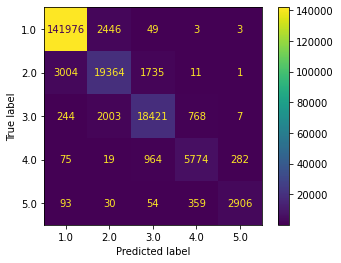

<Figure size 1440x1296 with 0 Axes>

In [66]:
from sklearn import metrics
import matplotlib.pyplot as plt

confusion_matrix = metrics.confusion_matrix(y_valid, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [1.0, 2.0, 3.0, 4.0, 5.0])
cm_display.plot()
plt.figure(figsize=(20,18))
plt.show()

We have achieved a high quality of predctions across each categories.  There is a small amount of false positive and true positive. Errors are often from one class to one nearby. It is a acceptable - the mispredictions of dangerous level of PM2.5 as a healthy one is minimal.  

